In [19]:
%load_ext autoreload
%autoreload 2
from dynamics import ClohessyWiltshire
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# -----------------------------------------------------------------------------
# Physical and orbital parameters (Section IV.A, Table 1)
# -----------------------------------------------------------------------------
mu_E   = 3.986e5          # km^3/s^2, Earth gravitational parameter
R_E    = 6378.0           # km, Earth radius
alt    = 705.0            # km, target altitude
a_orb  = R_E + alt        # km, semi-major axis of target orbit
n_mm   = np.sqrt(mu_E / a_orb**3)   # rad/s, mean motion of target
m_chs  = 6500.0           # kg, chaser mass

# -----------------------------------------------------------------------------
# Discretize with zero-order hold (Section II.B)
# -----------------------------------------------------------------------------
Td = 15.0  # s, sample period (Table 1)

# -----------------------------------------------------------------------------
# Cost weights and Riccati terminal weight
# -----------------------------------------------------------------------------
Q  = np.diag([1, 1, 1, 100, 100, 100])
R  = np.diag([100, 100, 100])

# -----------------------------------------------------------------------------
# MPC parameters
# -----------------------------------------------------------------------------
N            = 30      # horizon length (Table 1)
u_max        = 20.0    # N, per-axis thrust limit
hold_dist    = 2.3     # m, mission terminates within this radius of target
max_steps    = 200     # safety cap
# Initial conditions (Table 1)
x0 = np.array([50.0, -1000.0, 10.0, 0.0, 0.0, 0.0])
xt = np.zeros(6)

In [21]:
cw = ClohessyWiltshire(mu_E, R_E, alt, m_chs, Td)
cw.set_cost_params(Q, R)
cw.set_mpc_params(x0, xt, N, u_max, hold_dist, max_steps)
cw.simulate()

Reached holding distance (2.127 m) at step 70
Mission steps:       70  (1050 s = 17.5 min)
Total impulse:       20.02 kN*s
Mean solve time:     12.76 ms / step
Final dist to target 2.127 m


Saved plot to mpc_milestone1.png


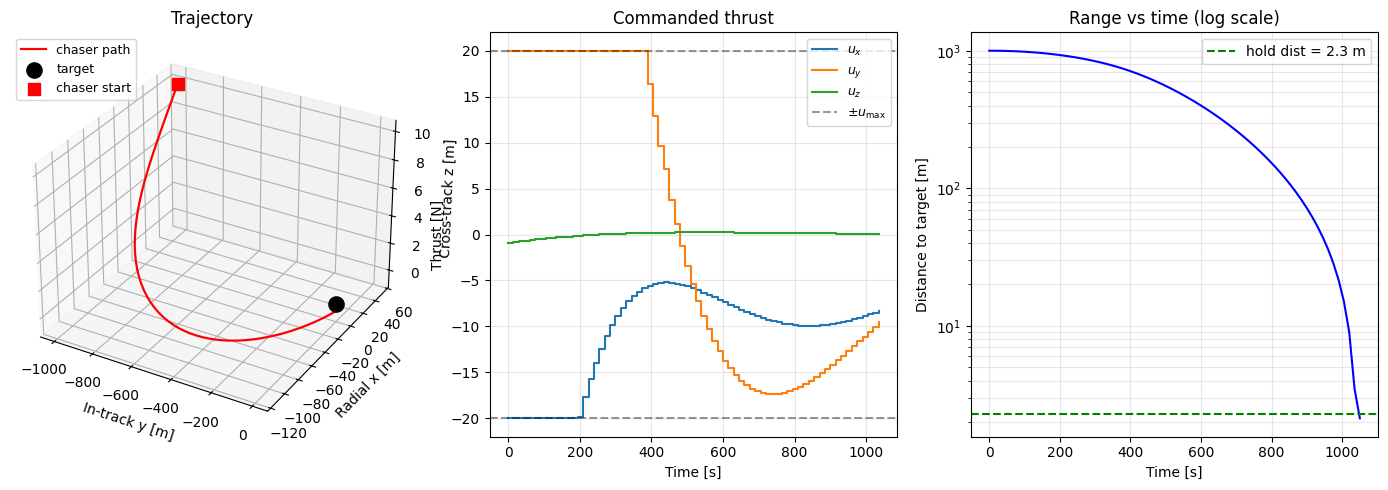

In [22]:
cw.plot_trajectory(cw.trajs, cw.ctrls)